In [1]:
from pathlib import Path

BASE_DIR = Path("e9_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e9_artifacts/logs
/content/e9_artifacts/tables
/content/e9_artifacts/figures


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
TEST_PATH = "test_final.csv"
BERT_MODEL_PATH = "/content/drive/MyDrive/rubert_tiny2_sentiment_model_tuned"

In [5]:
import pandas as pd

test_df = pd.read_csv(TEST_PATH)

print("test_df shape:", test_df.shape)
display(test_df.head())

test_df shape: (2211, 3)


,text,label,id
0,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
1,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136
2,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209
3,(пушка на Караульной горе больше не стреляет Б...,negative,1342696727808274432
4,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,1317052132382679041


In [6]:
X_test = test_df["text"].copy()
y_test = test_df["label"].copy()

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (2211,)
y_test: (2211,)


In [7]:
TRAIN_PATH = "train_final.csv"

train_df = pd.read_csv(TRAIN_PATH)

X_train = train_df["text"].copy()
y_train = train_df["label"].copy()

print("train_df shape:", train_df.shape)

train_df shape: (7957, 3)


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier

SEED = 42
LABEL_ORDER = ["negative", "neutral", "positive"]

char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

sgd_model = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

sgd_model.fit(X_train_char, y_train)
y_pred_classical = sgd_model.predict(X_test_char)

print("Classical predictions ready.")

Classical predictions ready.


In [9]:
!pip install -q transformers

In [10]:
import torch
import numpy as np
from torch.nn.functional import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_PATH)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_PATH)
bert_model.to(device)
bert_model.eval()

Device: cpu


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(83828, 312, padding_idx=0)
      (position_embeddings): Embedding(2048, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, 

In [11]:
def bert_predict_proba(texts, tokenizer, model, device, max_length=128, batch_size=32):
    all_probs = []
    texts = list(texts)

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            probs = softmax(outputs.logits, dim=-1).cpu().numpy()

        all_probs.append(probs)

    return np.vstack(all_probs)

In [12]:
proba_bert = bert_predict_proba(X_test, tokenizer, bert_model, device)
y_pred_bert_ids = np.argmax(proba_bert, axis=1)
y_pred_bert = np.array([LABEL_ORDER[i] for i in y_pred_bert_ids])

print("BERT predictions ready.")

BERT predictions ready.


In [13]:
from sklearn.calibration import CalibratedClassifierCV

sgd_base = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

sgd_cal = CalibratedClassifierCV(
    estimator=sgd_base,
    method="sigmoid",
    cv=3
)

sgd_cal.fit(X_train_char, y_train)
proba_classical = sgd_cal.predict_proba(X_test_char)

classical_class_order = list(sgd_cal.classes_)
reorder_indices = [classical_class_order.index(lbl) for lbl in LABEL_ORDER]
proba_classical = proba_classical[:, reorder_indices]

print("Calibrated classical probabilities ready.")

Calibrated classical probabilities ready.


In [15]:
HYBRID_WEIGHTS = np.array([0.4887, 0.5113], dtype=float)  # [classical, bert]
HYBRID_WEIGHTS = HYBRID_WEIGHTS / HYBRID_WEIGHTS.sum()

print("Hybrid weights:", HYBRID_WEIGHTS)

Hybrid weights: [0.4887 0.5113]


In [16]:
proba_hybrid = (
    HYBRID_WEIGHTS[0] * proba_classical +
    HYBRID_WEIGHTS[1] * proba_bert
)

y_pred_hybrid_ids = np.argmax(proba_hybrid, axis=1)
y_pred_hybrid = np.array([LABEL_ORDER[i] for i in y_pred_hybrid_ids])

print("Hybrid predictions ready.")

Hybrid predictions ready.


In [17]:
analysis_df = test_df.copy()

analysis_df["y_true"] = y_test.values
analysis_df["pred_classical"] = y_pred_classical
analysis_df["pred_bert"] = y_pred_bert
analysis_df["pred_hybrid"] = y_pred_hybrid

analysis_df["classical_correct"] = analysis_df["y_true"] == analysis_df["pred_classical"]
analysis_df["bert_correct"] = analysis_df["y_true"] == analysis_df["pred_bert"]
analysis_df["hybrid_correct"] = analysis_df["y_true"] == analysis_df["pred_hybrid"]

display(analysis_df.head())

,text,label,id,y_true,pred_classical,pred_bert,pred_hybrid,classical_correct,bert_correct,hybrid_correct
0,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576,positive,neutral,neutral,neutral,False,False,False
1,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136,positive,neutral,neutral,neutral,False,False,False
2,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209,neutral,neutral,neutral,neutral,True,True,True
3,(пушка на Караульной горе больше не стреляет Б...,negative,1342696727808274432,negative,neutral,negative,negative,False,True,True
4,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,1317052132382679041,positive,positive,positive,positive,True,True,True


In [18]:
analysis_df.to_csv(TABLE_DIR / "e9_full_prediction_analysis.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e9_full_prediction_analysis.csv")

Saved: e9_artifacts/tables/e9_full_prediction_analysis.csv


In [19]:
summary_counts = {
    "total_samples": len(analysis_df),
    "classical_errors": int((~analysis_df["classical_correct"]).sum()),
    "bert_errors": int((~analysis_df["bert_correct"]).sum()),
    "hybrid_errors": int((~analysis_df["hybrid_correct"]).sum()),
}

summary_counts

{'total_samples': 2211,
 'classical_errors': 703,
 'bert_errors': 670,
 'hybrid_errors': 603}

In [20]:
only_classical_wrong = analysis_df[
    (~analysis_df["classical_correct"]) &
    (analysis_df["bert_correct"]) &
    (analysis_df["hybrid_correct"])
].copy()

only_bert_wrong = analysis_df[
    (analysis_df["classical_correct"]) &
    (~analysis_df["bert_correct"]) &
    (analysis_df["hybrid_correct"])
].copy()

both_wrong_hybrid_correct = analysis_df[
    (~analysis_df["classical_correct"]) &
    (~analysis_df["bert_correct"]) &
    (analysis_df["hybrid_correct"])
].copy()

hybrid_wrong_but_one_base_correct = analysis_df[
    (~analysis_df["hybrid_correct"]) &
    (
        (analysis_df["classical_correct"]) |
        (analysis_df["bert_correct"])
    )
].copy()

all_wrong = analysis_df[
    (~analysis_df["classical_correct"]) &
    (~analysis_df["bert_correct"]) &
    (~analysis_df["hybrid_correct"])
].copy()

print("only_classical_wrong:", only_classical_wrong.shape)
print("only_bert_wrong:", only_bert_wrong.shape)
print("both_wrong_hybrid_correct:", both_wrong_hybrid_correct.shape)
print("hybrid_wrong_but_one_base_correct:", hybrid_wrong_but_one_base_correct.shape)
print("all_wrong:", all_wrong.shape)

only_classical_wrong: (220, 10)
only_bert_wrong: (137, 10)
both_wrong_hybrid_correct: (3, 10)
hybrid_wrong_but_one_base_correct: (195, 10)
all_wrong: (408, 10)


In [21]:
only_classical_wrong.to_csv(TABLE_DIR / "e9_only_classical_wrong.csv", index=False, encoding="utf-8-sig")
only_bert_wrong.to_csv(TABLE_DIR / "e9_only_bert_wrong.csv", index=False, encoding="utf-8-sig")
both_wrong_hybrid_correct.to_csv(TABLE_DIR / "e9_both_wrong_hybrid_correct.csv", index=False, encoding="utf-8-sig")
hybrid_wrong_but_one_base_correct.to_csv(TABLE_DIR / "e9_hybrid_wrong_but_base_correct.csv", index=False, encoding="utf-8-sig")
all_wrong.to_csv(TABLE_DIR / "e9_all_wrong.csv", index=False, encoding="utf-8-sig")

print("Saved all error-group tables.")

Saved all error-group tables.


In [26]:
def build_confusion_pairs(df, pred_col, model_name):
    wrong_df = df[df["y_true"] != df[pred_col]].copy()

    pair_counts = (
        wrong_df.groupby(["y_true", pred_col])
        .size()
        .reset_index(name="count")
        .rename(columns={pred_col: "y_pred"})
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    pair_counts["model"] = model_name
    return pair_counts

pairs_classical = build_confusion_pairs(analysis_df, "pred_classical", "classical")
pairs_bert = build_confusion_pairs(analysis_df, "pred_bert", "bert")
pairs_hybrid = build_confusion_pairs(analysis_df, "pred_hybrid", "hybrid")

pairs_all = pd.concat([pairs_classical, pairs_bert, pairs_hybrid], ignore_index=True)
display(pairs_all.head(20))

,y_true,y_pred,count,model
0,negative,neutral,243,classical
1,positive,neutral,183,classical
2,neutral,negative,123,classical
3,positive,negative,63,classical
4,neutral,positive,60,classical
5,negative,positive,31,classical
6,negative,neutral,176,bert
7,neutral,negative,166,bert
8,positive,neutral,128,bert
9,neutral,positive,85,bert


In [27]:
pairs_all.to_csv(TABLE_DIR / "e9_confusion_pairs.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e9_confusion_pairs.csv")

Saved: e9_artifacts/tables/e9_confusion_pairs.csv


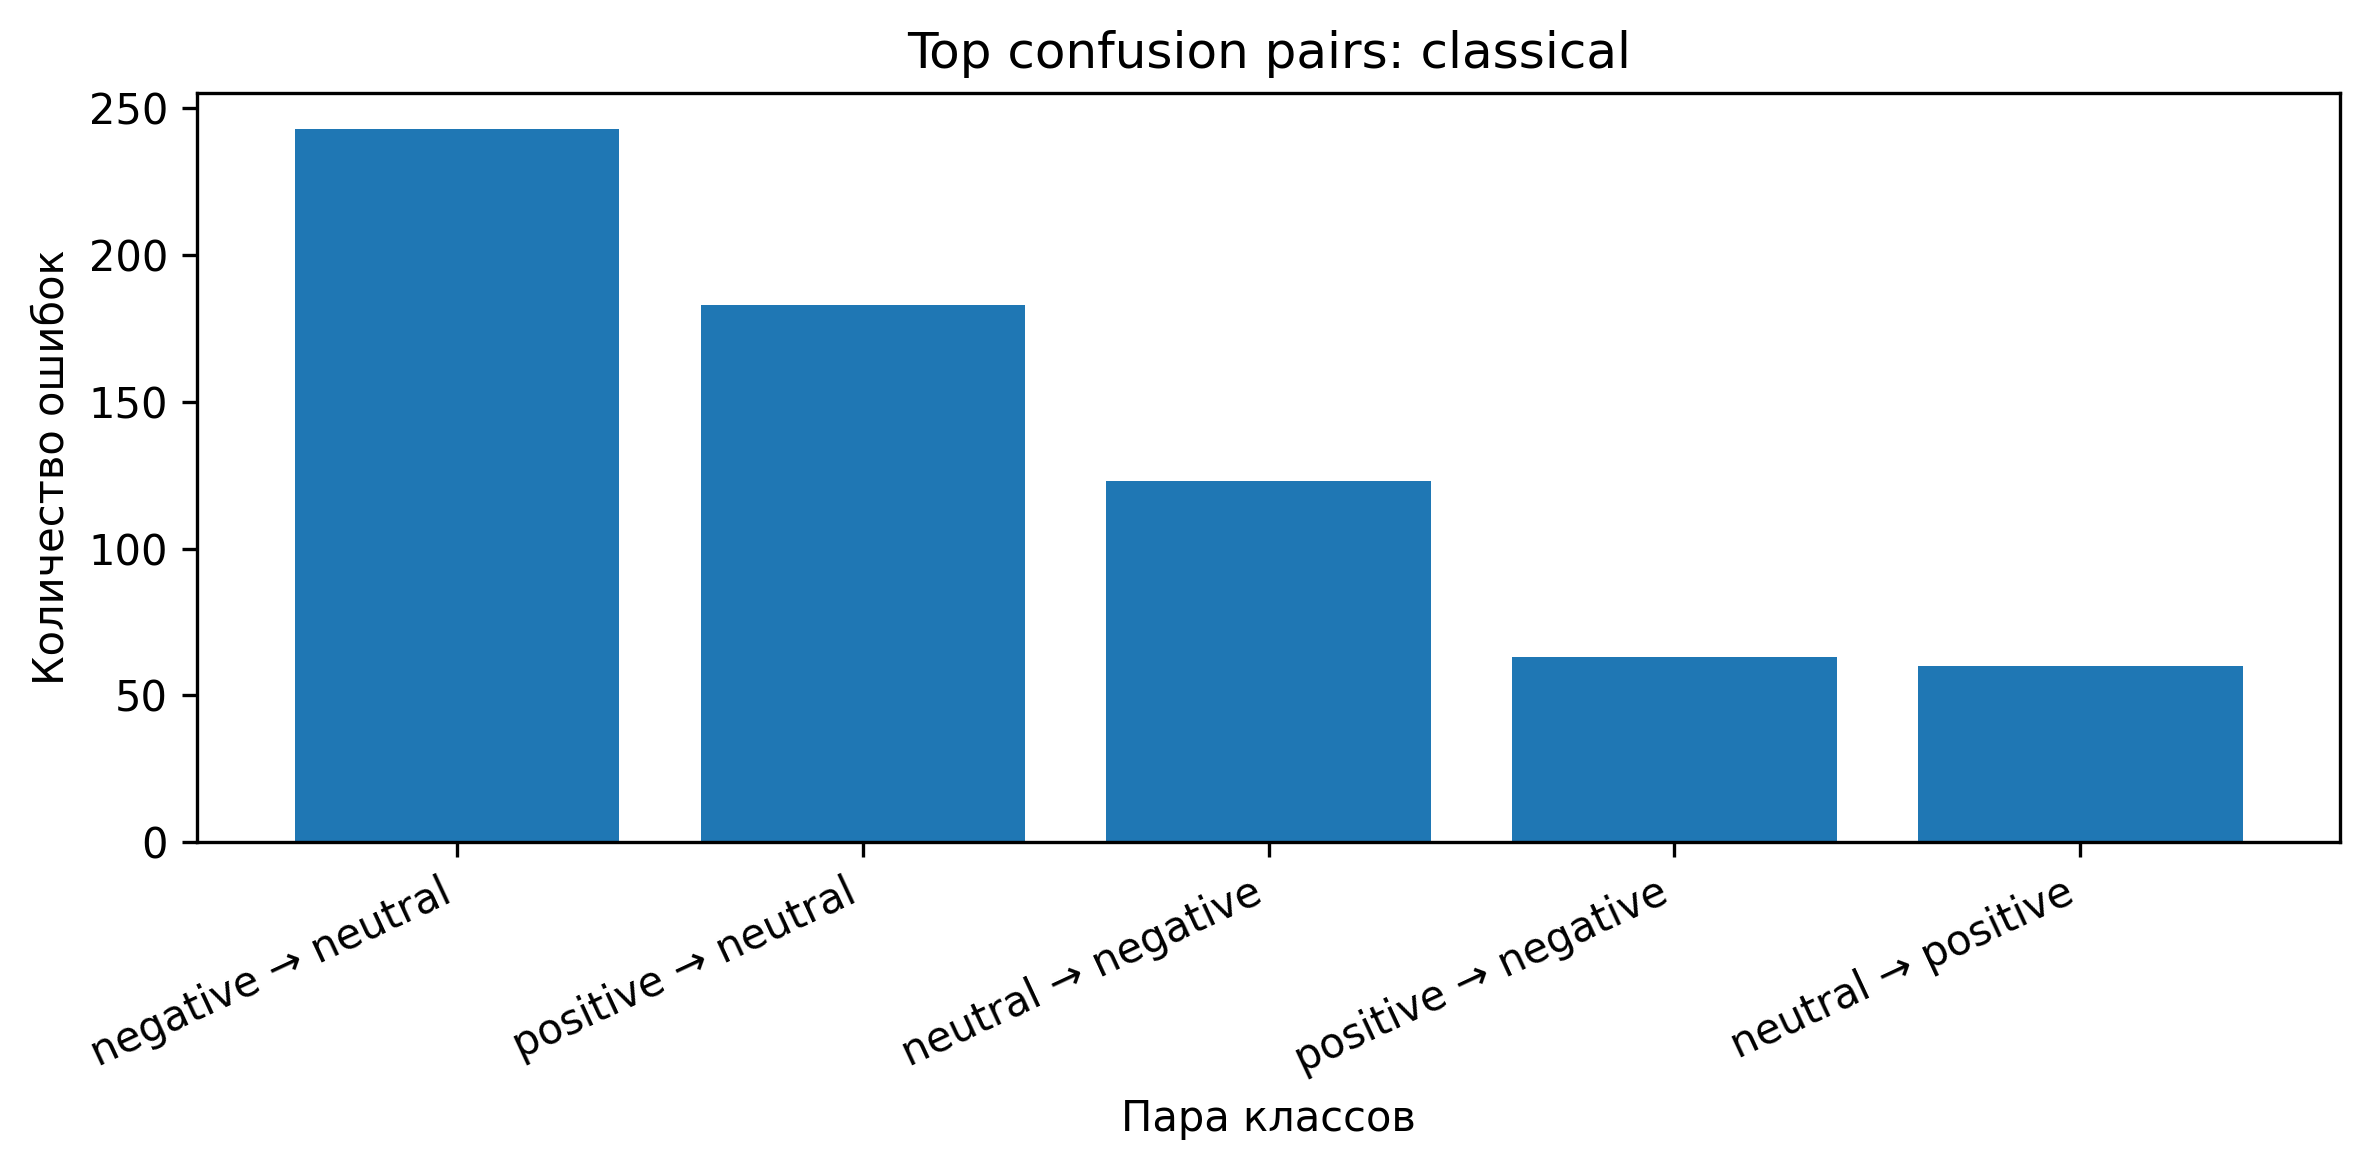

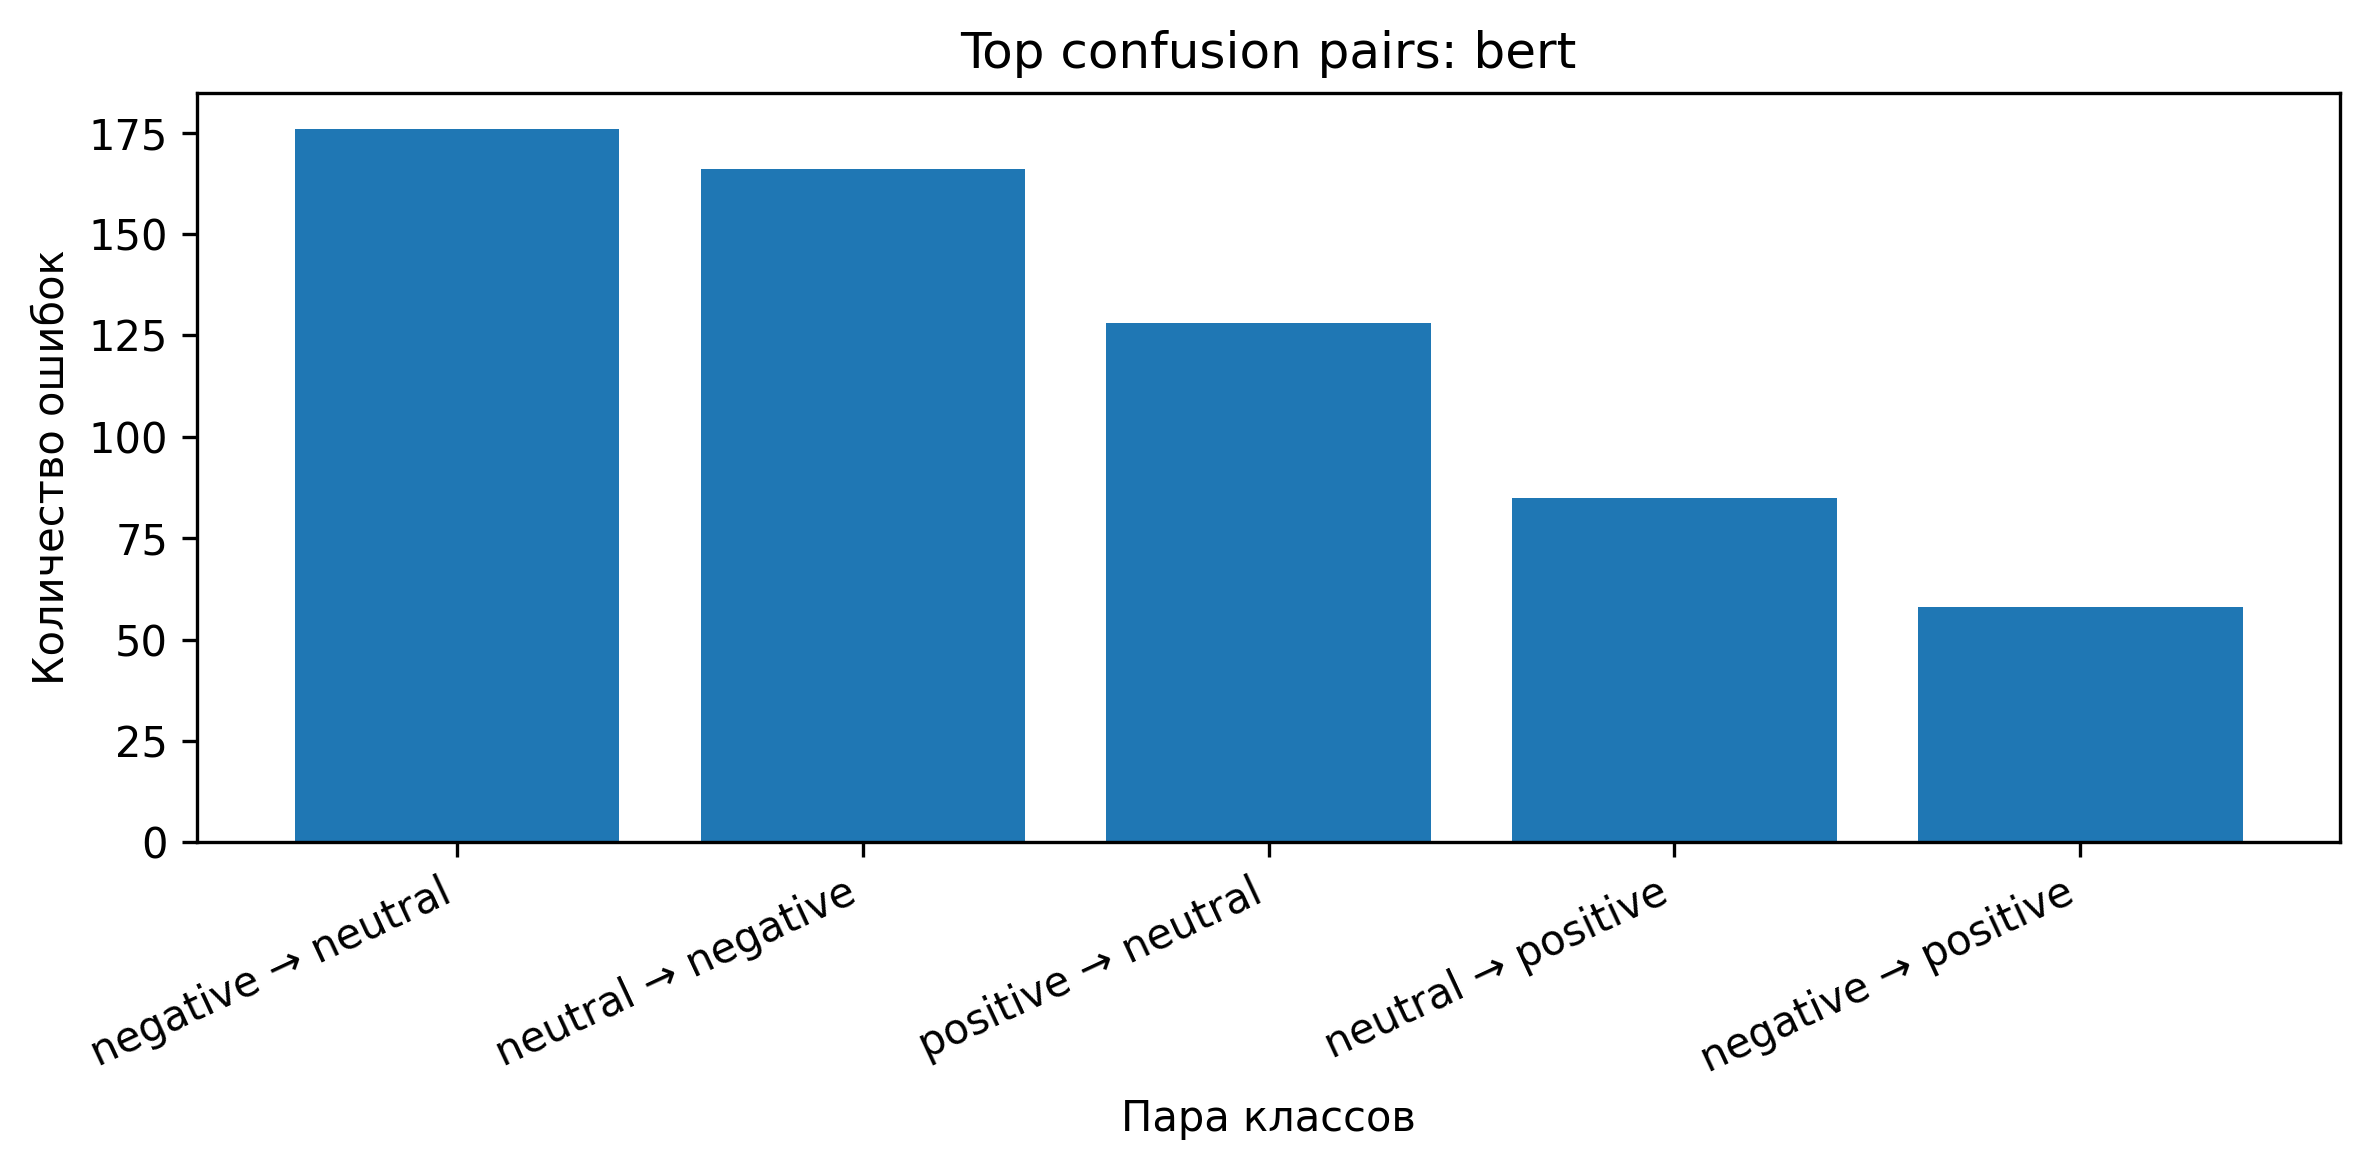

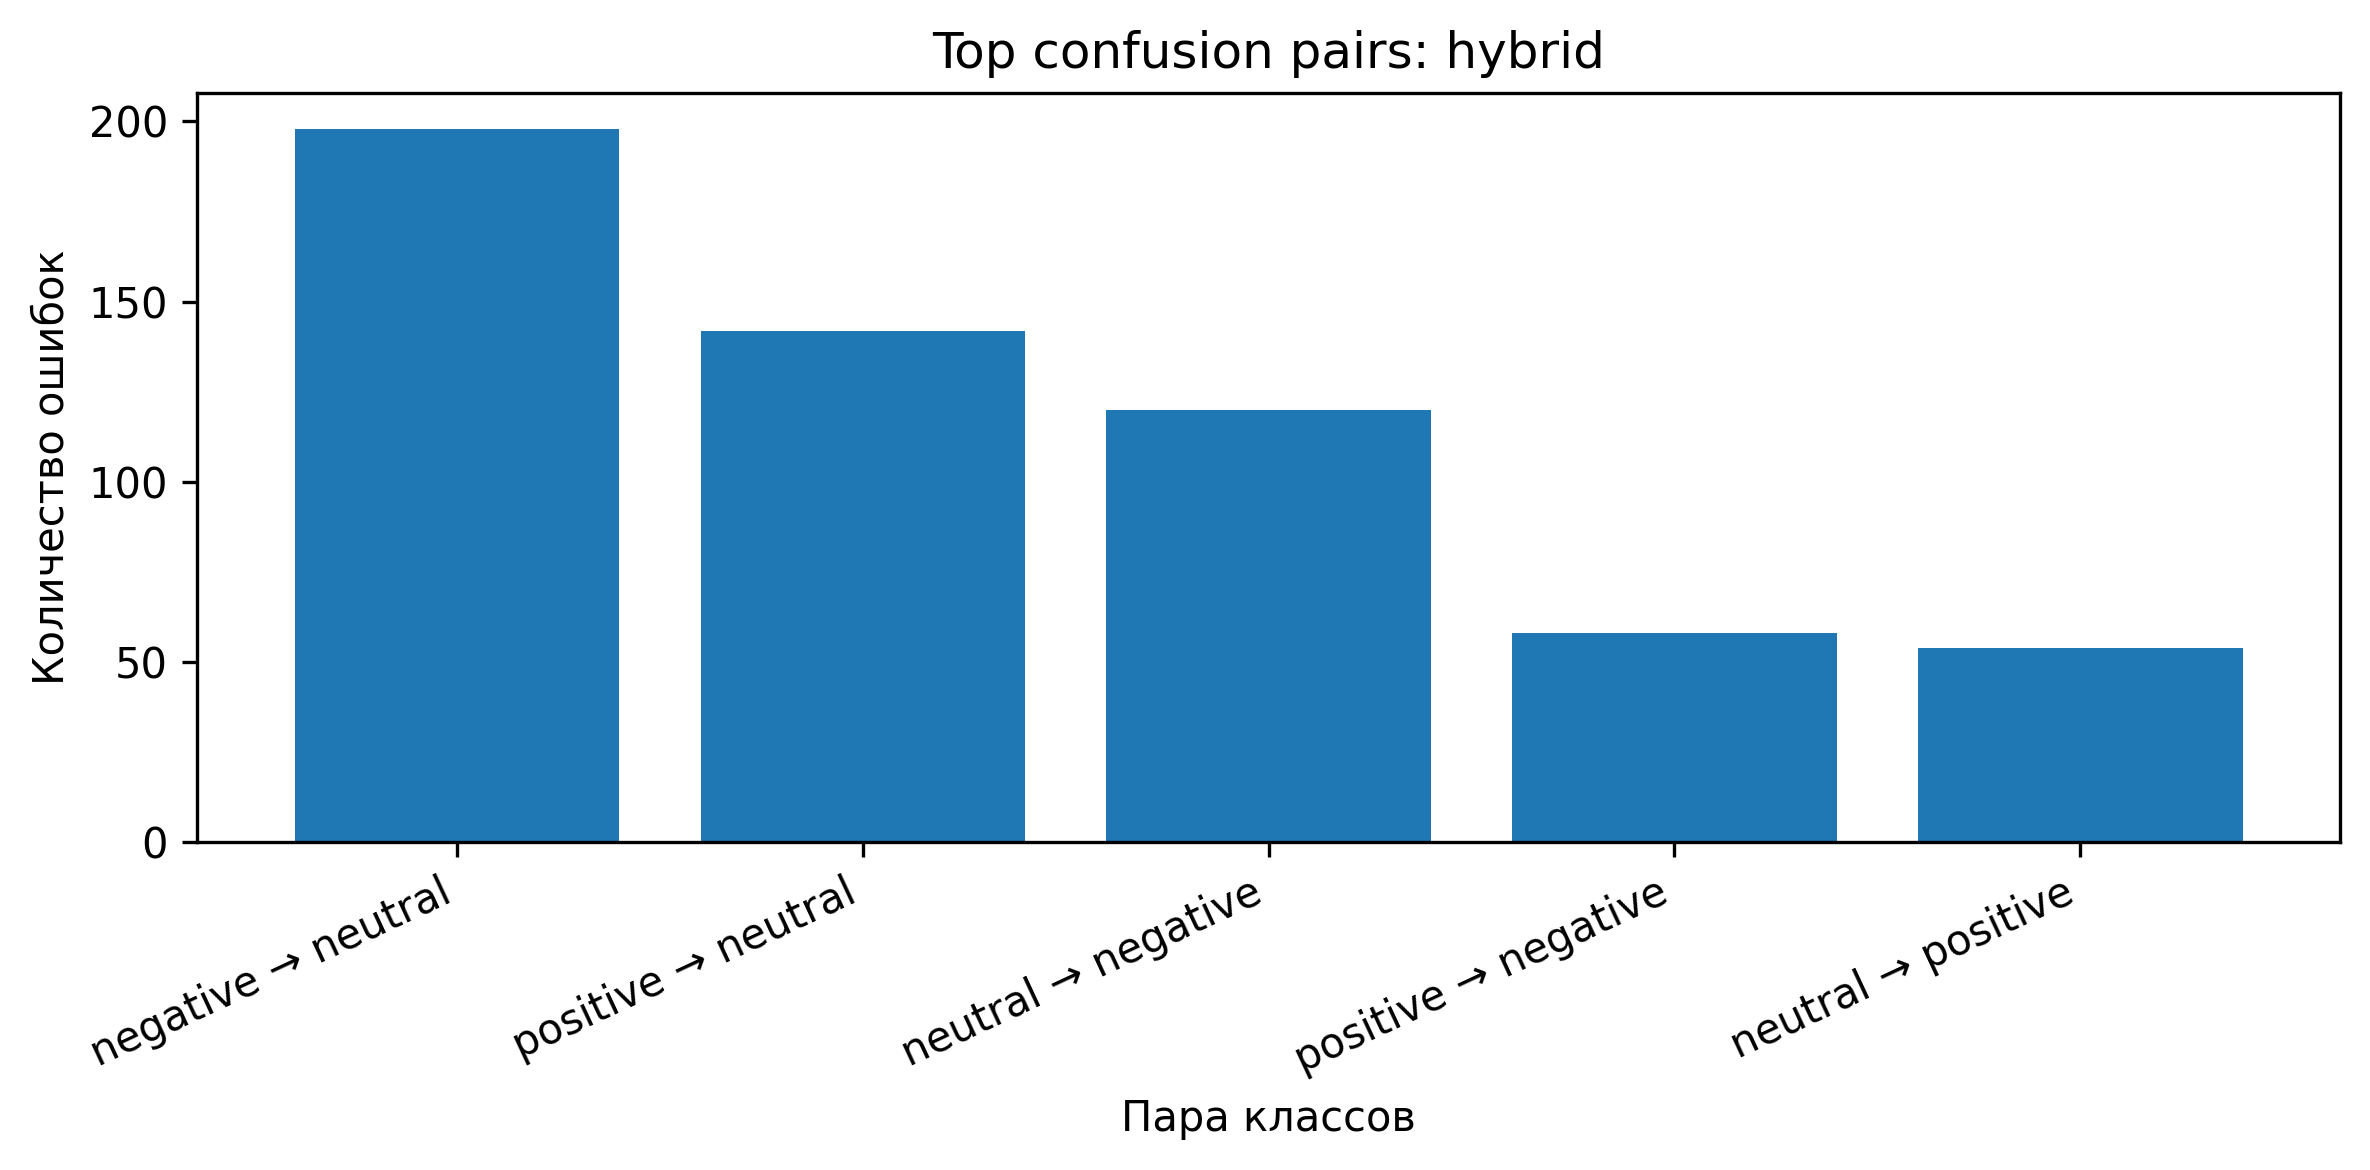

In [28]:
import matplotlib.pyplot as plt

for model_name in ["classical", "bert", "hybrid"]:
    sub = pairs_all[pairs_all["model"] == model_name].head(5).copy()
    sub["pair"] = sub["y_true"] + " → " + sub[sub.columns[1]]

    plt.figure(figsize=(8, 4), dpi=300)
    plt.bar(sub["pair"], sub["count"])
    plt.title(f"Top confusion pairs: {model_name}")
    plt.xlabel("Пара классов")
    plt.ylabel("Количество ошибок")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"e9_top_confusion_pairs_{model_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [29]:
pairs_all.to_csv(TABLE_DIR / "e9_confusion_pairs.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e9_confusion_pairs.csv")

Saved: e9_artifacts/tables/e9_confusion_pairs.csv


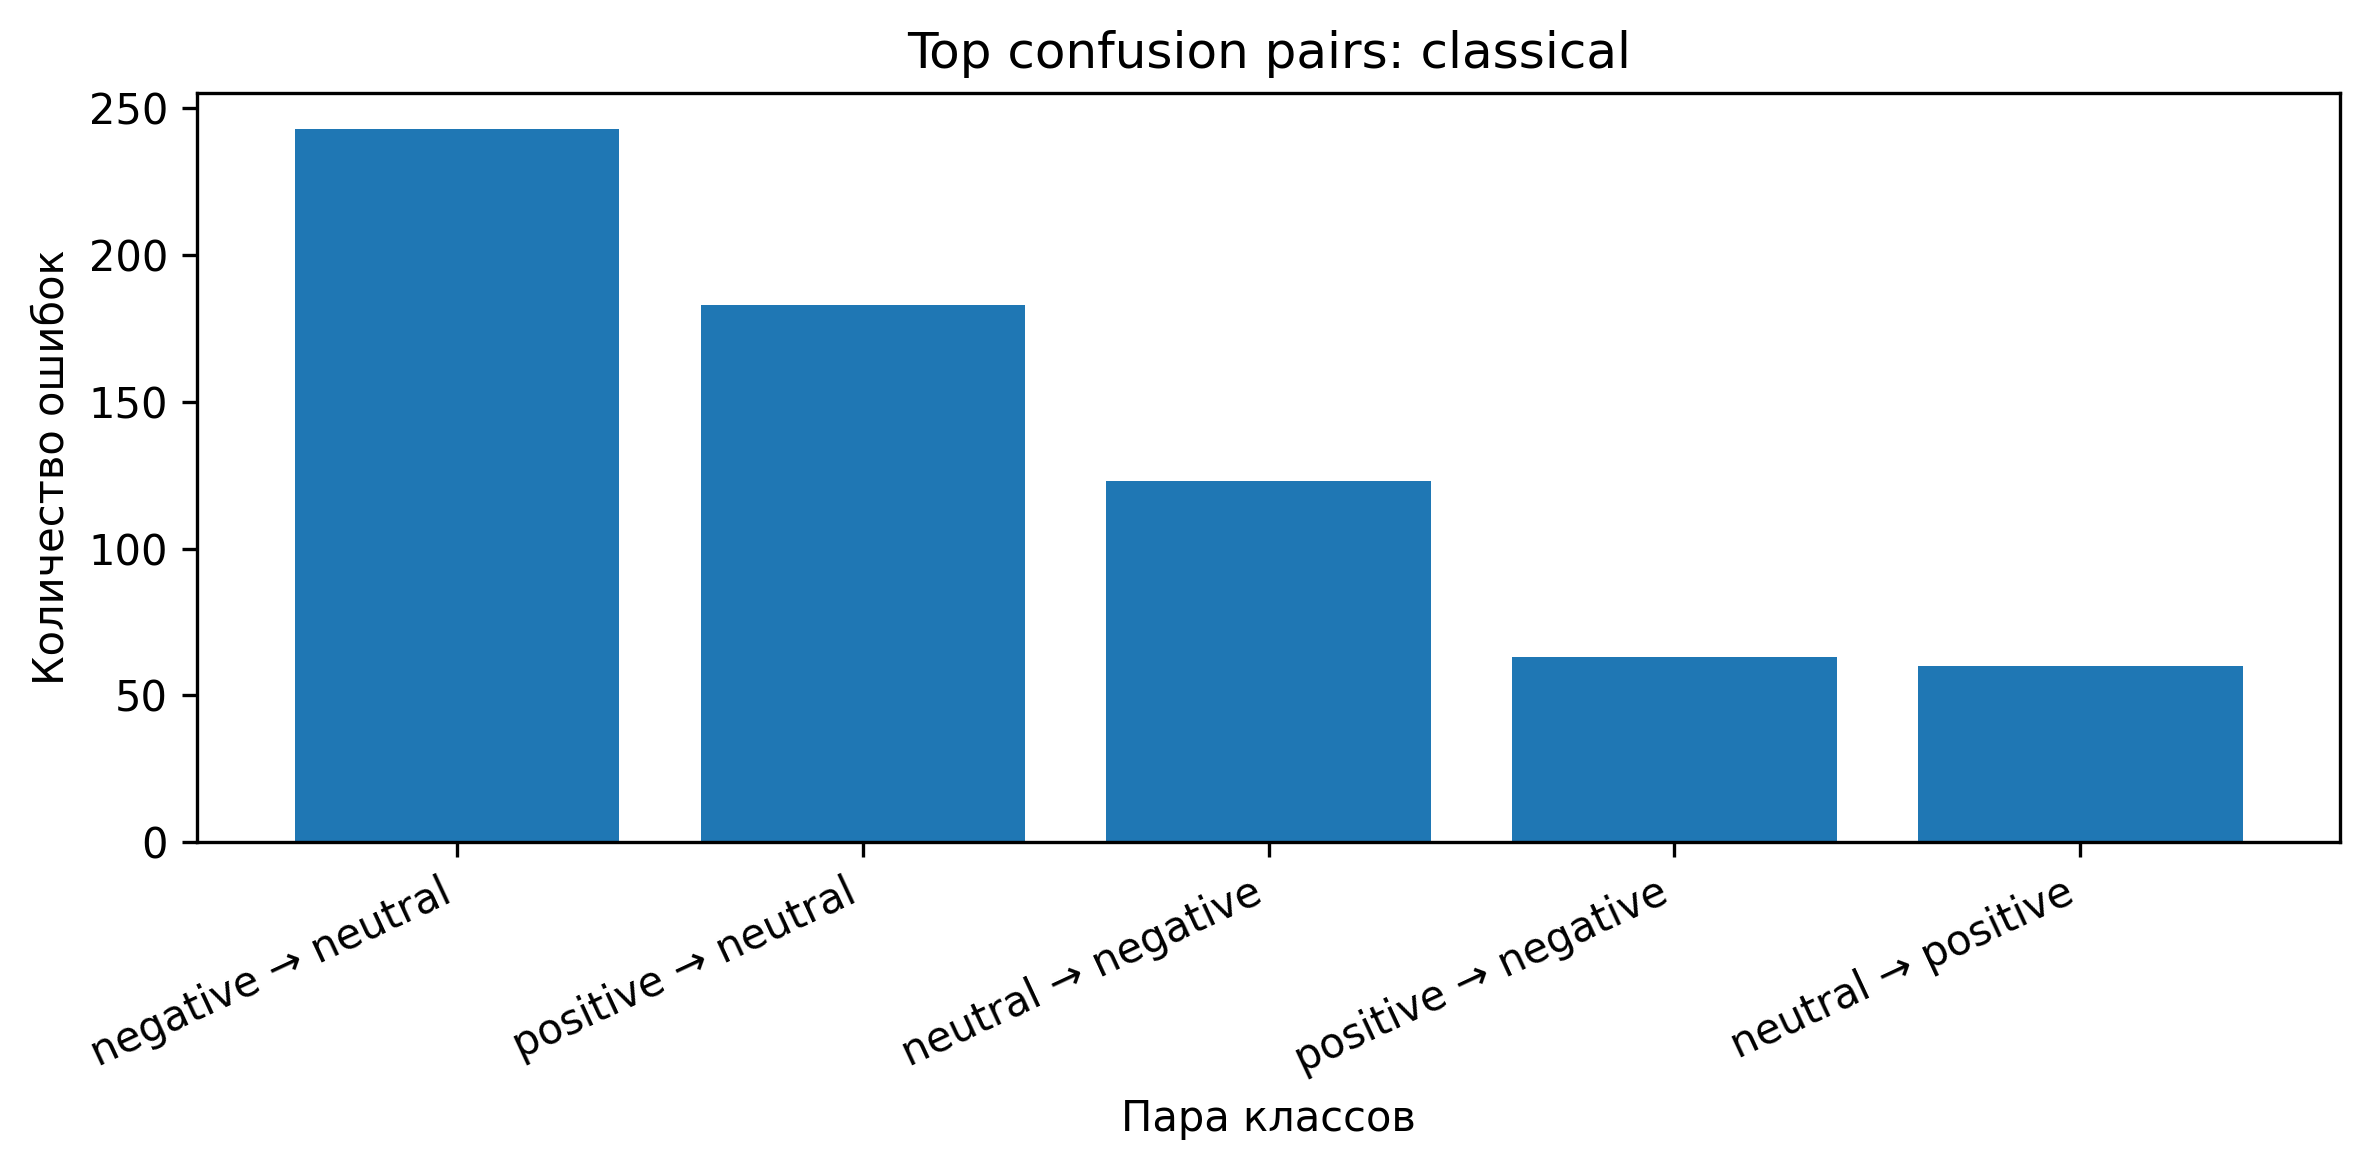

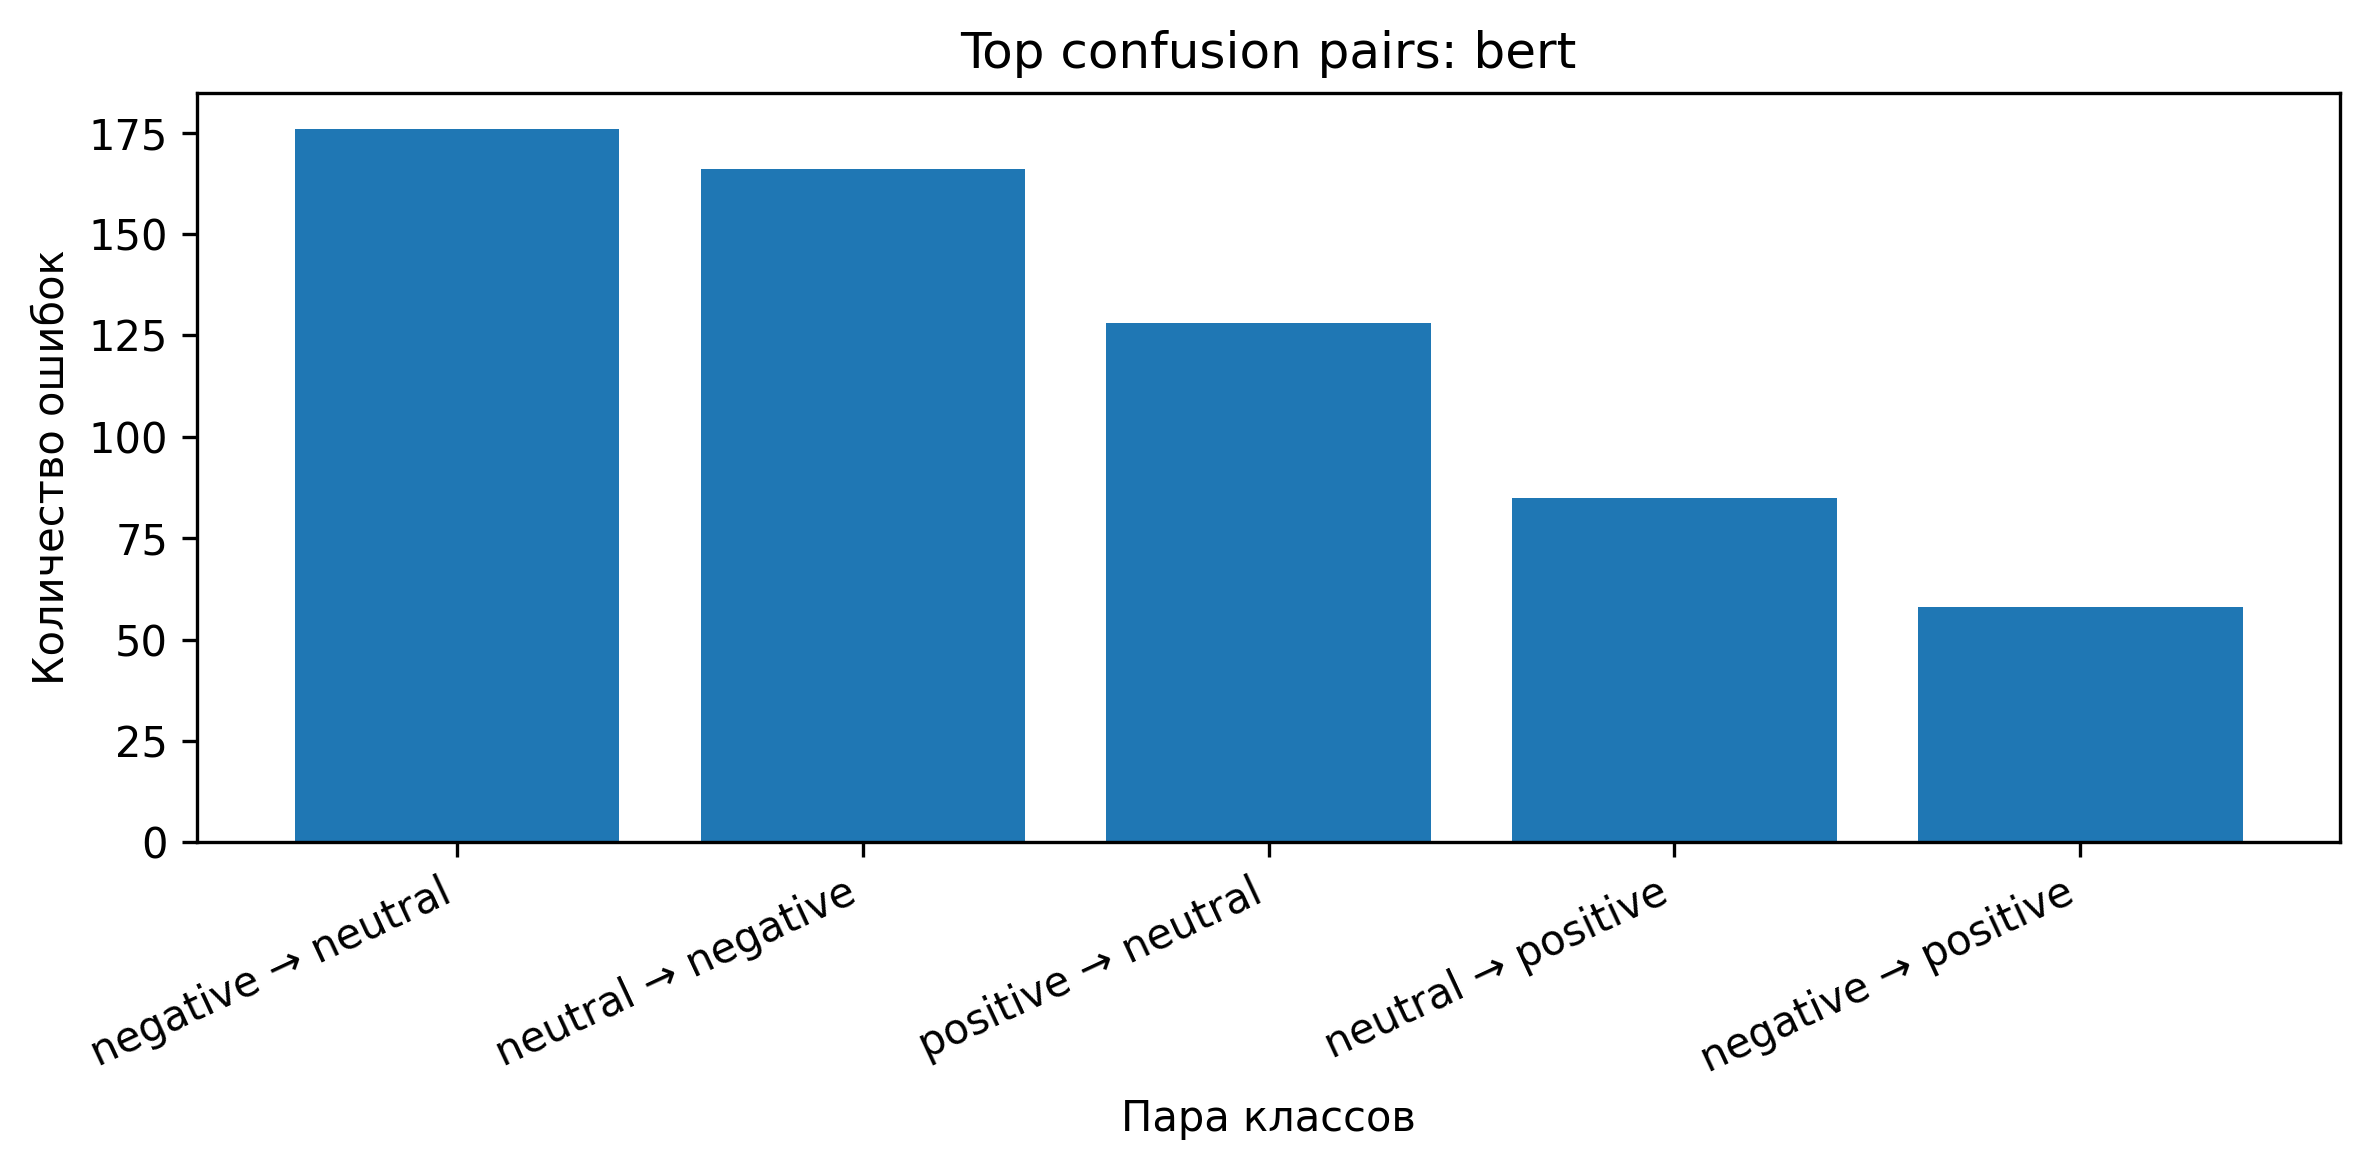

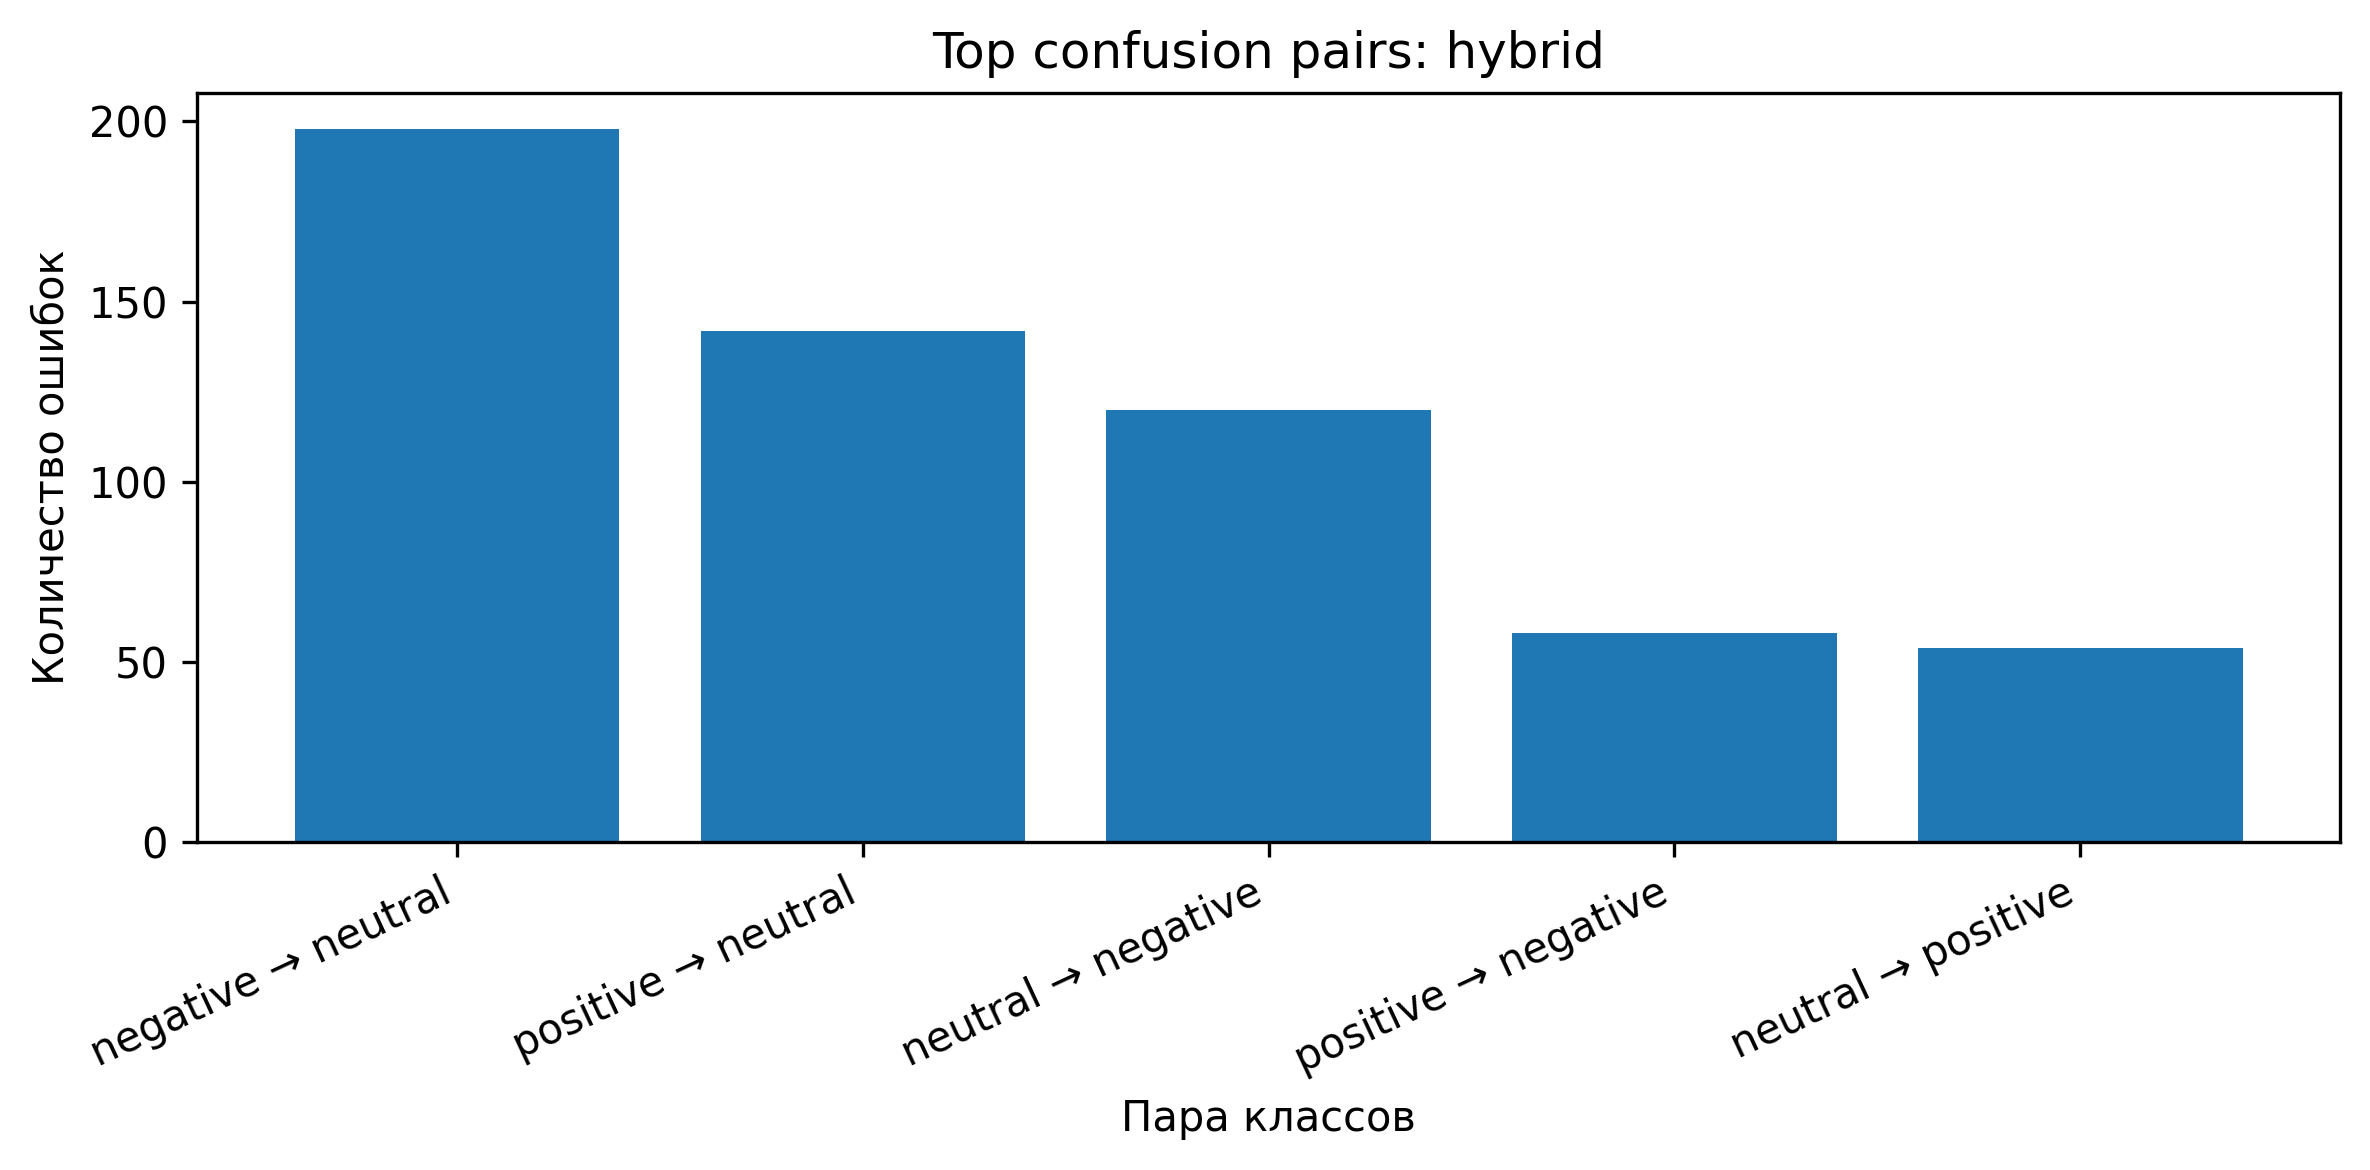

In [30]:
import matplotlib.pyplot as plt

for model_name in ["classical", "bert", "hybrid"]:
    sub = pairs_all[pairs_all["model"] == model_name].head(5).copy()
    sub["pair"] = sub["y_true"] + " → " + sub[sub.columns[1]]

    plt.figure(figsize=(8, 4), dpi=300)
    plt.bar(sub["pair"], sub["count"])
    plt.title(f"Top confusion pairs: {model_name}")
    plt.xlabel("Пара классов")
    plt.ylabel("Количество ошибок")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"e9_top_confusion_pairs_{model_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [31]:
sample_only_classical_wrong = only_classical_wrong.head(15).copy()
sample_only_bert_wrong = only_bert_wrong.head(15).copy()
sample_both_wrong_hybrid_correct = both_wrong_hybrid_correct.head(15).copy()
sample_all_wrong = all_wrong.head(15).copy()

In [32]:
sample_only_classical_wrong.to_csv(TABLE_DIR / "e9_sample_only_classical_wrong.csv", index=False, encoding="utf-8-sig")
sample_only_bert_wrong.to_csv(TABLE_DIR / "e9_sample_only_bert_wrong.csv", index=False, encoding="utf-8-sig")
sample_both_wrong_hybrid_correct.to_csv(TABLE_DIR / "e9_sample_both_wrong_hybrid_correct.csv", index=False, encoding="utf-8-sig")
sample_all_wrong.to_csv(TABLE_DIR / "e9_sample_all_wrong.csv", index=False, encoding="utf-8-sig")

print("Saved sample tables for manual inspection.")

Saved sample tables for manual inspection.


In [33]:
manual_review_df = pd.concat([
    sample_only_classical_wrong.assign(group="only_classical_wrong"),
    sample_only_bert_wrong.assign(group="only_bert_wrong"),
    sample_both_wrong_hybrid_correct.assign(group="both_wrong_hybrid_correct"),
    sample_all_wrong.assign(group="all_wrong")
], ignore_index=True)

manual_review_df["error_reason"] = ""
manual_review_df["comment"] = ""

manual_review_df.to_csv(TABLE_DIR / "e9_manual_review_template.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e9_manual_review_template.csv")

Saved: e9_artifacts/tables/e9_manual_review_template.csv


In [34]:
e9_summary_text = f"""
E9 ERROR ANALYSIS SUMMARY

Dataset:
RuSentiTweet test_final

Models compared:
- classical: SGDClassifier hinge + char TF-IDF (3,5)
- bert: ruBERT-tiny2 tuned
- hybrid: weighted ensemble

Total samples:
{len(analysis_df)}

Error counts:
classical_errors = {(~analysis_df["classical_correct"]).sum()}
bert_errors = {(~analysis_df["bert_correct"]).sum()}
hybrid_errors = {(~analysis_df["hybrid_correct"]).sum()}

Intersection groups:
only_classical_wrong = {len(only_classical_wrong)}
only_bert_wrong = {len(only_bert_wrong)}
both_wrong_hybrid_correct = {len(both_wrong_hybrid_correct)}
hybrid_wrong_but_one_base_correct = {len(hybrid_wrong_but_one_base_correct)}
all_wrong = {len(all_wrong)}

Top confusion pairs by model:
{pairs_all.groupby("model").head(5).to_string(index=False)}
"""

with open(LOG_DIR / "e9_summary.txt", "w", encoding="utf-8") as f:
    f.write(e9_summary_text)

print("Saved:", LOG_DIR / "e9_summary.txt")

Saved: e9_artifacts/logs/e9_summary.txt
